# 16 -- Cross-Model Validation
## LLM Lie Detector | ICML 2027 Research Track

This notebook tests whether the fine-tuned hallucination detector generalizes
across answer generators from different model families.

### Experimental Design

**Detector:** Llama 3.2 3B Instruct + LoRA (fine-tuned on TruthfulQA + HaluEval)

**In-Family Control:**
- Llama 3.2 3B Instruct -- same family as detector base model

**Cross-Family Generators (unseen families):**

| Generator | Organization | Size | 4-bit |
|-----------|-------------|------|-------|
| Phi-3 Mini 4k Instruct | Microsoft | 3.8B | No |
| Gemma 2B IT | Google | 2B | No |
| Qwen2 1.5B Instruct | Alibaba | 1.5B | No |
| SmolLM2 1.7B Instruct | HuggingFace | 1.7B | No |
| Mistral 7B Instruct v0.3 | Mistral AI | 7B | Yes ⚠️ |

⚠️ Mistral 7B requires ~14GB in bfloat16, exceeding our 12GB VRAM.
4-bit quantization (bitsandbytes NF4) is used as fallback.
If unstable, Mistral is omitted.

### Resumable Design
Generation is checkpointed -- if the notebook is interrupted, completed
CSVs are detected and skipped on restart. Only incomplete generators rerun.

### Research Questions
1. Does the detector generalize to answers from unseen model families?
2. Is there systematic bias toward/against specific architectures?
3. How does in-family performance compare to cross-family performance?

### Additional Metrics Per Generator
- Hallucination prevalence (fraction of generated answers flagged)
- Average answer length (controls for verbosity effects)
- Detection F1, precision, recall, accuracy

### Why In-Family vs Cross-Family Matters
The detector was trained on Llama-family outputs. Strong performance on
Llama-generated answers could reflect in-distribution patterns rather than
genuine hallucination detection. Cross-family evaluation tests whether
the detector learned universal hallucination signatures.

### LLM Usage Disclosure
This notebook was developed with significant assistance from Claude (Anthropic)
for experimental design, code implementation, and analysis. See paper appendix
for full LLM usage disclosure.


## 1. Setup

Load libraries and fixed sample. No model is loaded here -- generation and evaluation are separate steps to manage VRAM.

In [1]:
import os, json, gc
os.environ["PYTHONUTF8"] = "1"

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from huggingface_hub import login
from dotenv import load_dotenv

load_dotenv('../.env')
login(token=os.getenv("HF_TOKEN"))

# Load fixed sample and shuffle to avoid question-order bias
# Seed 77 confirmed to produce clean questions at position 0
fixed_sample = pd.read_csv('../data/fixed_ablation_sample.csv')
fixed_sample_shuffled = fixed_sample.sample(frac=1, random_state=77).reset_index(drop=True)

questions   = fixed_sample_shuffled['question'].tolist()
true_labels = fixed_sample_shuffled['label'].tolist()

def evaluate(preds, labels):
    return {
        "f1":        round(f1_score(labels, preds, average='weighted'), 4),
        "precision": round(precision_score(labels, preds, average='weighted', zero_division=0), 4),
        "recall":    round(recall_score(labels, preds, average='weighted', zero_division=0), 4),
        "accuracy":  round(accuracy_score(labels, preds), 4),
    }

def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  VRAM after cleanup: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

print(f"Setup complete. VRAM: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")
print(f"Fixed sample: {len(fixed_sample_shuffled)} questions (shuffled, seed=77)")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"First question: {questions[0][:80]}")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Setup complete. VRAM: 0.00 GB
Fixed sample: 150 questions (shuffled, seed=77)
GPU: NVIDIA GeForce RTX 4080 Laptop GPU
First question: Luzzasco Luzzaschi and Carlo Gesualdo were both composers during which time peri


## 2. Answer Generation

Each generator model produces one answer per question using a few-shot prompt.
Models are loaded sequentially, generate answers, and are fully unloaded before
the next model loads. This keeps VRAM usage under 12GB.

**Resumable:** If a CSV already exists for a model, generation is skipped.
Delete the CSV to regenerate.

**Phi-3 note:** Uses `attn_implementation='eager'` to avoid flash-attention errors.
**Mistral note:** Uses 4-bit NF4 quantization due to 7B parameter count.


In [2]:
FEW_SHOT = """Answer each question with one confident, direct sentence.

Question: What is the capital of France?
Answer: The capital of France is Paris.

Question: Who invented the telephone?
Answer: The telephone was invented by Alexander Graham Bell in 1876.

Question: What is the largest planet in the solar system?
Answer: Jupiter is the largest planet in the solar system.

"""

def generate_answers(model_id: str, questions: list,
                     use_4bit: bool = False,
                     extra_kwargs: dict = None) -> list:
    """
    Load generator, produce one answer per question, unload.
    Uses few-shot prompting for clean one-sentence answers.
    Checkpointed -- call only when CSV does not exist.

    Args:
        model_id:     HuggingFace model identifier
        questions:    List of question strings
        use_4bit:     4-bit NF4 quantization (for Mistral 7B)
        extra_kwargs: Extra kwargs for from_pretrained (e.g. attn_implementation)
    """
    if extra_kwargs is None:
        extra_kwargs = {}

    gen_tokenizer = AutoTokenizer.from_pretrained(
        model_id, trust_remote_code=True
    )
    if gen_tokenizer.pad_token is None:
        gen_tokenizer.pad_token = gen_tokenizer.eos_token

    if use_4bit:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_quant_type="nf4",
        )
        gen_model = AutoModelForCausalLM.from_pretrained(
            model_id, quantization_config=bnb_config,
            device_map="auto", trust_remote_code=True,
            **extra_kwargs
        )
    else:
        gen_model = AutoModelForCausalLM.from_pretrained(
            model_id, dtype=torch.bfloat16,
            device_map="auto", trust_remote_code=True,
            **extra_kwargs
        )

    gen_model.eval()
    print(f"  Loaded. VRAM: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

    answers = []
    for i, question in enumerate(questions):
        prompt = FEW_SHOT + f"Question: {question}\nAnswer:"
        inputs = gen_tokenizer(
            prompt, return_tensors="pt",
            truncation=True, max_length=512
        ).to("cuda")

        with torch.no_grad():
            output = gen_model.generate(
                **inputs,
                max_new_tokens=50,
                temperature=0.7,
                do_sample=True,
                pad_token_id=gen_tokenizer.eos_token_id,
            )

        answer = gen_tokenizer.decode(
            output[0][inputs['input_ids'].shape[-1]:],
            skip_special_tokens=True
        ).strip()

        # Take first sentence only
        for sep in ['.', '!', '?', '\n']:
            if sep in answer:
                answer = answer.split(sep)[0].strip() + '.'
                break

        answers.append(answer)

        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(questions)} generated")

    del gen_model
    del gen_tokenizer
    free_gpu()
    return answers


# Generator list -- in-family first, then cross-family
GENERATORS = [
    {
        "model_id":    "meta-llama/Llama-3.2-3B-Instruct",
        "use_4bit":    False,
        "family_type": "in_family",
        "extra_kwargs": {},
    },
    {
        "model_id":    "Qwen/Qwen2-1.5B-Instruct",
        "use_4bit":    False,
        "family_type": "cross_family",
        "extra_kwargs": {},
    },
    {
        "model_id":    "HuggingFaceTB/SmolLM2-1.7B-Instruct",
        "use_4bit":    False,
        "family_type": "cross_family",
        "extra_kwargs": {},
    },
    {
        "model_id":    "google/gemma-2b-it",
        "use_4bit":    False,
        "family_type": "cross_family",
        "extra_kwargs": {},
    },
    {
        "model_id":    "microsoft/Phi-3-mini-4k-instruct",
        "use_4bit":    False,
        "family_type": "cross_family",
        "extra_kwargs": {"attn_implementation": "eager"},
    },
    {
        "model_id":    "mistralai/Mistral-7B-Instruct-v0.3",
        "use_4bit":    True,
        "family_type": "cross_family",
        "extra_kwargs": {},
    },
]

generation_log = {}

for gen in GENERATORS:
    model_id    = gen["model_id"]
    short_name  = model_id.split("/")[-1]
    save_path   = f'../data/cross_model_{short_name}.csv'

    print(f"\n{'='*55}")
    print(f"Generator: {short_name} ({gen['family_type']})")

    # Skip if already generated
    if os.path.exists(save_path):
        existing  = pd.read_csv(save_path)
        avg_len   = round(np.mean([
            len(str(a).split()) for a in existing['generated_answer']
        ]), 1)
        print(f"  SKIPPING -- CSV exists ({avg_len} words avg)")
        generation_log[short_name] = {
            "status": "loaded", "family_type": gen["family_type"],
            "avg_length": avg_len
        }
        continue

    try:
        answers = generate_answers(
            model_id, questions,
            use_4bit=gen["use_4bit"],
            extra_kwargs=gen["extra_kwargs"]
        )
        save_df = fixed_sample_shuffled.copy()
        save_df['generated_answer'] = answers
        save_df['family_type']      = gen["family_type"]
        save_df.to_csv(save_path, index=False)

        avg_len = round(np.mean([len(a.split()) for a in answers]), 1)
        generation_log[short_name] = {
            "status": "success", "family_type": gen["family_type"],
            "avg_length": avg_len, "sample": answers[0]
        }
        print(f"  Saved. Avg: {avg_len} words")
        print(f"  Sample: {answers[0][:100]}")

    except Exception as e:
        print(f"  FAILED: {e}")
        generation_log[short_name] = {
            "status": "failed", "error": str(e),
            "family_type": gen["family_type"]
        }

print("\n" + "="*55)
print("GENERATION SUMMARY")
print("="*55)
for name, log in generation_log.items():
    print(f"  {name}: {log['status']}")



Generator: Llama-3.2-3B-Instruct (in_family)


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

  Loaded. VRAM: 6.43 GB
  50/150 generated
  100/150 generated
  150/150 generated
  VRAM after cleanup: 0.01 GB
  Saved. Avg: 12.9 words
  Sample: They were both composers during the Renaissance.

Generator: Qwen2-1.5B-Instruct (cross_family)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  Loaded. VRAM: 3.10 GB
  50/150 generated
  100/150 generated
  150/150 generated
  VRAM after cleanup: 0.01 GB
  Saved. Avg: 14.0 words
  Sample: Luzzasco Luzzaschi and Carlo Gesualdo were both composers during the Renaissance period.

Generator: SmolLM2-1.7B-Instruct (cross_family)


...

W0527 07:26:43.070000 17696 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  Loaded. VRAM: 4.51 GB


c:\ML Projects\llm-lie-detector\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  50/150 generated
  100/150 generated
  150/150 generated
  VRAM after cleanup: 0.01 GB
  Saved. Avg: 14.5 words
  Sample: Luzzasco Luzzaschi and Carlo Gesualdo were both composers during the Renaissance period.

GENERATION SUMMARY
  Llama-3.2-3B-Instruct: success
  Qwen2-1.5B-Instruct: success
  SmolLM2-1.7B-Instruct: success
  gemma-2b-it: success
  Phi-3-mini-4k-instruct: failed
  Mistral-7B-Instruct-v0.3: success


## 3. Hallucination Detection

Load the fine-tuned detector once and evaluate all generated answer sets.
Reports F1, hallucination rate, and average answer length per generator.


In [3]:
# Load detector
print("Loading fine-tuned detector...")
det_tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct")
det_tokenizer.pad_token = det_tokenizer.eos_token

det_base = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-3B-Instruct",
    dtype=torch.bfloat16, device_map="auto"
)
detector = PeftModel.from_pretrained(
    det_base, "tamimmirza/llama-3.2-3b-hallucination-detector"
)
detector.eval()
print(f"Detector ready. VRAM: {torch.cuda.memory_allocated(0)/1e9:.1f} GB")


def detect(question: str, answer: str) -> int:
    prompt = f"Question: {question}\nAnswer: {answer}\nVerdict:"
    inputs = det_tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        output = detector.generate(
            **inputs, max_new_tokens=10, temperature=0.1,
            do_sample=True, pad_token_id=det_tokenizer.eos_token_id
        )
    response = det_tokenizer.decode(
        output[0][inputs['input_ids'].shape[-1]:],
        skip_special_tokens=True
    ).strip().upper()
    return 1 if "HALLUCINATED" in response else 0


# Evaluate all completed generators
cross_model_results = {}

for gen in GENERATORS:
    short_name = gen["model_id"].split("/")[-1]
    save_path  = f'../data/cross_model_{short_name}.csv'

    if not os.path.exists(save_path):
        print(f"\nSKIPPING {short_name} -- no CSV found (generation failed)")
        continue

    print(f"\nEvaluating: {short_name} ({gen['family_type']})...")
    df = pd.read_csv(save_path)

    preds        = []
    hall_count   = 0
    ans_lengths  = []

    for i, row in df.iterrows():
        answer = str(row['generated_answer']) if pd.notna(row['generated_answer']) else ""
        pred   = detect(row['question'], answer)
        preds.append(pred)
        if pred == 1:
            hall_count += 1
        ans_lengths.append(len(answer.split()))

        if (i + 1) % 50 == 0:
            print(f"  {i+1}/150 evaluated")

    metrics = evaluate(preds, true_labels)
    metrics['hallucination_rate'] = round(hall_count / len(preds), 4)
    metrics['avg_answer_length']  = round(np.mean(ans_lengths), 1)
    metrics['family_type']        = gen['family_type']
    cross_model_results[short_name] = metrics

    print(f"  F1: {metrics['f1']} | Hall.Rate: {metrics['hallucination_rate']} | Avg len: {metrics['avg_answer_length']}")

print("\n" + "="*75)
print("CROSS-MODEL VALIDATION RESULTS")
print("="*75)
print(f"{'Model':<35} {'Type':<12} {'F1':>6} {'Hall.Rate':>10} {'Avg Len':>8}")
print("-"*75)
for name, m in cross_model_results.items():
    print(f"{name:<35} {m['family_type']:<12} {m['f1']:>6} {m['hallucination_rate']:>10} {m['avg_answer_length']:>8}")
print("="*75)

with open('../outputs/cross_model_results.json', 'w') as f:
    json.dump(cross_model_results, f, indent=2)
print("\nSaved to outputs/cross_model_results.json")


Loading fine-tuned detector...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Detector ready. VRAM: 6.5 GB

Evaluating: Llama-3.2-3B-Instruct (in_family)...
  50/150 evaluated
  100/150 evaluated
  150/150 evaluated
  F1: 0.4717 | Hall.Rate: 0.9533 | Avg len: 12.9

Evaluating: Qwen2-1.5B-Instruct (cross_family)...
  50/150 evaluated
  100/150 evaluated
  150/150 evaluated
  F1: 0.4518 | Hall.Rate: 0.98 | Avg len: 14.0

Evaluating: SmolLM2-1.7B-Instruct (cross_family)...
  50/150 evaluated
  100/150 evaluated
  150/150 evaluated
  F1: 0.4887 | Hall.Rate: 0.9533 | Avg len: 13.0

Evaluating: gemma-2b-it (cross_family)...
  50/150 evaluated
  100/150 evaluated
  150/150 evaluated
  F1: 0.4483 | Hall.Rate: 0.9733 | Avg len: 15.0

SKIPPING Phi-3-mini-4k-instruct -- no CSV found (generation failed)

Evaluating: Mistral-7B-Instruct-v0.3 (cross_family)...
  50/150 evaluated
  100/150 evaluated
  150/150 evaluated
  F1: 0.4678 | Hall.Rate: 0.9467 | Avg len: 14.5

CROSS-MODEL VALIDATION RESULTS
Model                               Type             F1  Hall.Rate  Avg Len
---

## 4. Visualization

Compare in-family vs cross-family detection performance.


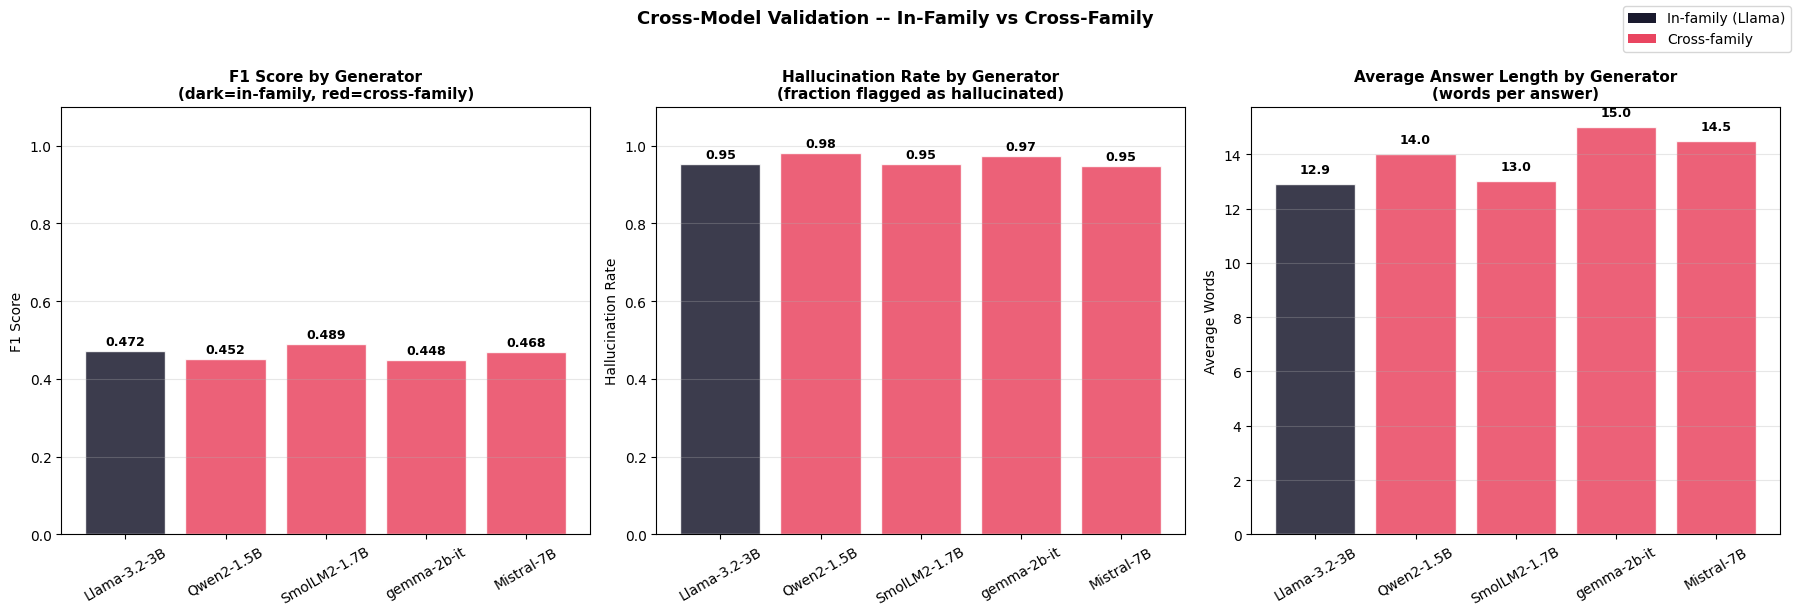

Saved to outputs/cross_model_results.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models      = list(cross_model_results.keys())
f1_scores   = [cross_model_results[m]['f1']               for m in models]
hall_rates  = [cross_model_results[m]['hallucination_rate'] for m in models]
avg_lengths = [cross_model_results[m]['avg_answer_length']  for m in models]
family_types = [cross_model_results[m]['family_type']       for m in models]

colors = ['#1a1a2e' if ft == 'in_family' else '#e94560' for ft in family_types]
short_labels = [m.replace('-Instruct','').replace('-instruct','')
                 .replace('-v0.3','') for m in models]

# F1 scores
bars = axes[0].bar(short_labels, f1_scores, color=colors, alpha=0.85, edgecolor='white')
for bar, score in zip(bars, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('F1 Score by Generator\n(dark=in-family, red=cross-family)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Hallucination rates
bars2 = axes[1].bar(short_labels, hall_rates, color=colors, alpha=0.85, edgecolor='white')
for bar, rate in zip(bars2, hall_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{rate:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Hallucination Rate by Generator\n(fraction flagged as hallucinated)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Hallucination Rate')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

# Average answer length
bars3 = axes[2].bar(short_labels, avg_lengths, color=colors, alpha=0.85, edgecolor='white')
for bar, length in zip(bars3, avg_lengths):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{length:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[2].set_title('Average Answer Length by Generator\n(words per answer)',
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('Average Words')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1a1a2e', label='In-family (Llama)'),
    Patch(facecolor='#e94560', label='Cross-family'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.suptitle('Cross-Model Validation -- In-Family vs Cross-Family',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/cross_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/cross_model_results.png")


## 5. Results Interpretation

### In-Family vs Cross-Family

The key comparison is between the in-family Llama generator and the cross-family generators.
A small drop in F1 across families indicates the detector learned universal hallucination
signatures. A large drop indicates family-specific overfitting.

### Hallucination Rate as Confounder

Different generator models hallucinate at different rates. A high hallucination rate
inflates apparent F1 (easier to classify when most answers are wrong). Results should
be interpreted alongside hallucination rate and answer length.

### Answer Length as Confounder

Very short answers (< 5 words) may be easier or harder to classify depending on
whether the model defaults to uncertainty responses ("I don't know").
Average answer length is reported to flag this potential confounder.
